Installazione dipendenze

In [ ]:
#python -m pip install tensorflow tensorflow-datasets sentence-transformers scikit-learn matplotlib pillow importlib-resources

Import e configurazoine

In [1]:
# ==============================================================================
# PROGETTO M5 - CHEFBOT AI
# "Dallo scatto alla ricetta"
# ==============================================================================
#
# Il progetto integra tre componenti:
#
# 1. COMPUTER VISION
#    Classificazione delle immagini di cibo tramite Transfer Learning.
#
# 2. KNOWLEDGE RETRIEVAL
#    Recupero di ingredienti, calorie e descrizione da un database JSON.
#
# 3. SEMANTIC SEARCH
#    Ricerca del piatto più simile semanticamente a una frase dell'utente.
#
# ==============================================================================

import json
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow_datasets as tfds

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sentence_transformers import SentenceTransformer
from sentence_transformers.util import cos_sim


# ==============================================================================
# CONFIGURAZIONE GENERALE
# ==============================================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

EPOCHS_HEAD = 10
EPOCHS_FINE_TUNING = 8

LEARNING_RATE_HEAD = 1e-3
LEARNING_RATE_FINE = 1e-5

AUTOTUNE = tf.data.AUTOTUNE

HEAD_MODEL_PATH = "chefbot_head.keras"
FINE_MODEL_PATH = "chefbot_finetuned.keras"
FINAL_MODEL_PATH = "chefbot_final.keras"

KNOWLEDGE_PATH = "chefbot_knowledge.json"

print("TensorFlow:", tf.__version__)
print("GPU disponibili:", tf.config.list_physical_devices("GPU"))

c:\EPICODE\Epicode_Python_AI_MachineLearning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow: 2.21.0
GPU disponibili: []


Scelta delle classi di Food101 (ne scelgo 10)

In [2]:
# ==============================================================================
# CLASSI FOOD101 SELEZIONATE
# ==============================================================================

SELECTED_CLASSES = [
    "apple_pie",
    "caesar_salad",
    "cheesecake",
    "fish_and_chips",
    "greek_salad",
    "hamburger",
    "ice_cream",
    "lasagna",
    "pizza",
    "sushi"
]

NUM_CLASSES = len(SELECTED_CLASSES)

print(f"Numero classi selezionate: {NUM_CLASSES}")

for i, class_name in enumerate(SELECTED_CLASSES):
    print(f"{i:2d} -> {class_name}")

Numero classi selezionate: 10
 0 -> apple_pie
 1 -> caesar_salad
 2 -> cheesecake
 3 -> fish_and_chips
 4 -> greek_salad
 5 -> hamburger
 6 -> ice_cream
 7 -> lasagna
 8 -> pizza
 9 -> sushi


Caricamento Food101

In [10]:
# ==============================================================================
# CARICAMENTO DATASET FOOD101
# ==============================================================================

print("Caricamento Food101...")

# Carco il dataset (già diviso in train e validation
(ds_train, dt_test), df_info = tfds.load("food101", split=["train", "validation"], shuffle_files=True, as_supervised=True, with_info=True)
print("Dataset caricato correttamente.")

print("\nInformazioni dataset:")
print(df_info)

print("\nNumero classi originali:")
print(df_info.features["label"].num_classes)

Caricamento Food101...
Dataset caricato correttamente.

Informazioni dataset:
tfds.core.DatasetInfo(
    name='food101',
    full_name='food101/2.0.0',
    description="""
    This dataset consists of 101 food categories, with 101'000 images. For each class, 250 manually reviewed test images are provided as well as 750 training images. On purpose, the training images were not cleaned, and thus still contain some amount of noise. This comes mostly in the form of intense colors and sometimes wrong labels. All images were rescaled to have a maximum side length of 512 pixels.
    """,
    homepage='https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/',
    data_dir='C:\\Users\\barbara\\tensorflow_datasets\\food101\\2.0.0',
    file_format=tfrecord,
    download_size=4.65 GiB,
    dataset_size=4.77 GiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=101),
    }),
    supervised_key

Recupero i numeri associai alle mie classi

In [12]:
# ==============================================================================
# RECUPERO DELLE LABEL ORIGINALI FOOD101
# ==============================================================================

ALL_CLASS_NAMES = (df_info.features["label"].names)
print("Numero originale classi:",len(ALL_CLASS_NAMES))
print("Numero classi selezionate:",len(SELECTED_CLASSES))
selected_original_ids = [ALL_CLASS_NAMES.index(class_name) for class_name in SELECTED_CLASSES]
print("Elenco classi selezionate:")
for class_name, original_id in zip(SELECTED_CLASSES,selected_original_ids):
    print(f"{original_id:3d} -> {class_name}")

Numero originale classi: 101
Numero classi selezionate: 10
Elenco classi selezionate:
  0 -> apple_pie
 11 -> caesar_salad
 16 -> cheesecake
 38 -> fish_and_chips
 48 -> greek_salad
 53 -> hamburger
 58 -> ice_cream
 59 -> lasagna
 76 -> pizza
 95 -> sushi


Filtro il dataset per utilizzare solo le classi selezionate

In [14]:
# ==============================================================================
# FILTRO DEL DATASET
# ==============================================================================

# trasformo da lista python ad oggetto TensoFlow
selected_ids_tensor = tf.constant(selected_original_ids, dtype=tf.int64)

def is_selected(image,label):
    """
    Restituisce True solamente se la label appartiene alle classi selezionate.
    """
    return tf.reduce_any(tf.equal(label, selected_ids_tensor))
# ==============================================================================
# APPLICAZIONE DEL FILTRO
# ==============================================================================

ds_train = ds_train.filter(is_selected)
dt_test = dt_test.filter(is_selected)

print(f"Dataset filtrati")

Dataset filtrati


Rimappatura delle label

In [22]:
# ==============================================================================
# RIMAPPATURA LABEL
# ==============================================================================

keys = tf.constant(selected_original_ids,dtype=tf.int64)
values = tf.range(NUM_CLASSES,dtype=tf.int64)
label_lookup = tf.lookup.StaticHashTable(tf.lookup.KeyValueTensorInitializer(keys,values),default_value=-1)

def remap_label(image,label):

    """
    Converte la label originale
    Food101 nella nuova label
    compresa tra 0 e 14.
    """
    new_label = label_lookup.lookup(label)
    return (image,new_label)

ds_train = ds_train.map(remap_label,num_parallel_calls=AUTOTUNE)
dt_test = dt_test.map(remap_label,num_parallel_calls=AUTOTUNE)

print("Label rimappate correttamente.")

Label rimappate correttamente.


Controllo del dataset

In [ ]:
# ==============================================================================
# CONTEGGIO DELLE IMMAGINI PER CLASSE
# ==============================================================================

def count_classes(dataset):

    counts = np.zeros(NUM_CLASSES,dtype=int)
    for image, label in tfds.as_numpy(dataset):
        counts[int(label)] += 1
    return counts

In [36]:
train_counts = count_classes(ds_train)
test_counts = count_classes(dt_test)

print(f"---------------------------------------\nTRAIN\n---------------------------------------")

for class_name, count in zip(SELECTED_CLASSES,train_counts):
    print(f"{class_name:20s}: {count}")

print(f"---------------------------------------\nVALIDATION\n---------------------------------------")

for class_name, count in zip(SELECTED_CLASSES,test_counts):
    print(f"{class_name:20s}: {count}")

---------------------------------------
TRAIN
---------------------------------------
apple_pie           : 750
caesar_salad        : 750
cheesecake          : 750
fish_and_chips      : 750
greek_salad         : 750
hamburger           : 750
ice_cream           : 750
lasagna             : 750
pizza               : 750
sushi               : 750
---------------------------------------
VALIDATION
---------------------------------------
apple_pie           : 250
caesar_salad        : 250
cheesecake          : 250
fish_and_chips      : 250
greek_salad         : 250
hamburger           : 250
ice_cream           : 250
lasagna             : 250
pizza               : 250
sushi               : 250


Visualizzazione immagini

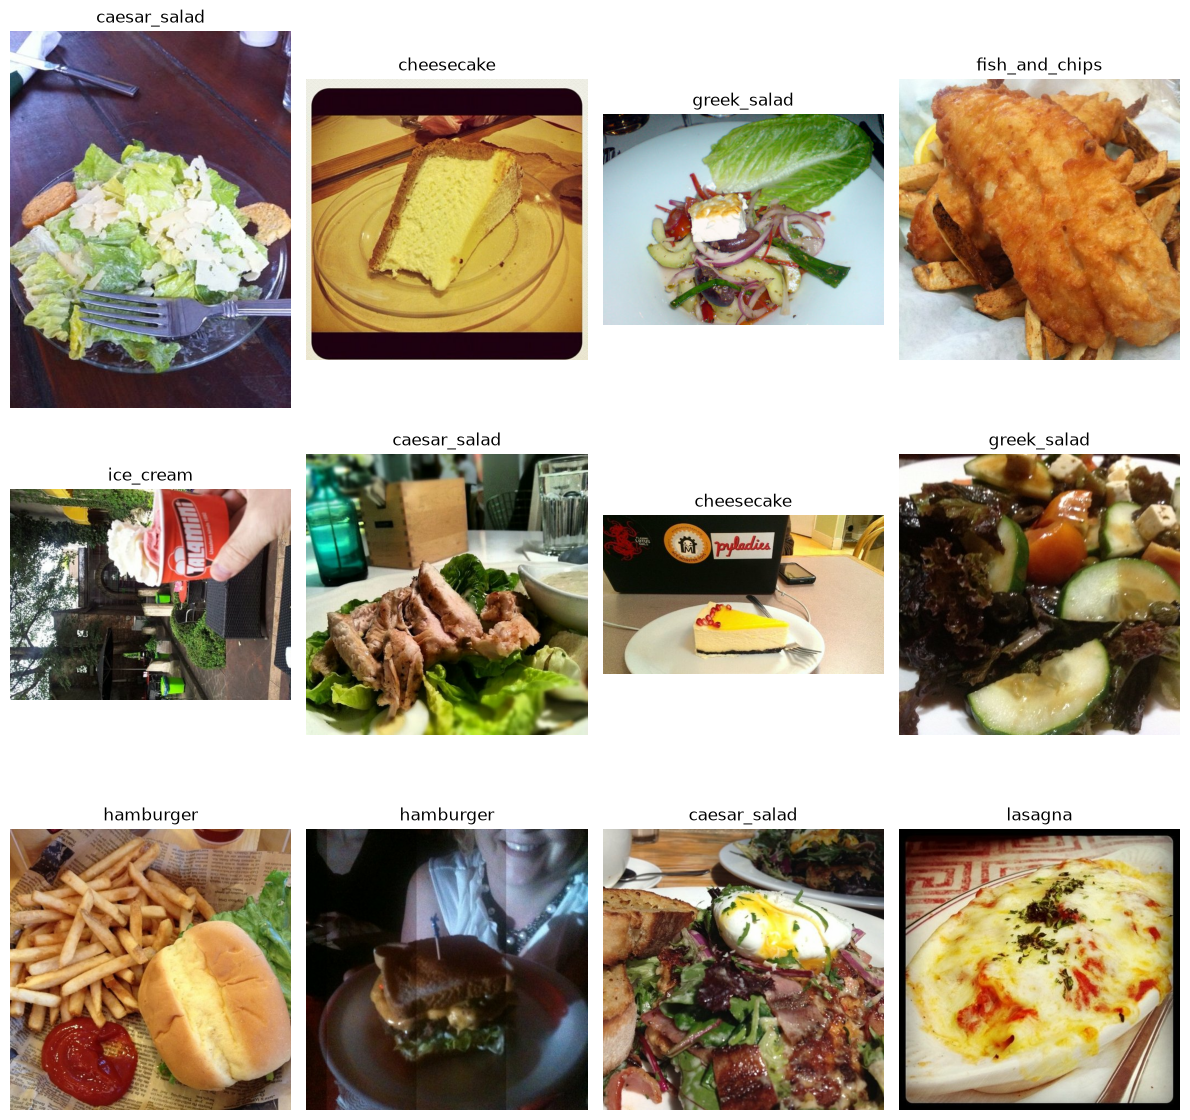

In [39]:
# ==============================================================================
# VISUALIZZAZIONE DI ALCUNE IMMAGINI
# ==============================================================================

plt.figure(figsize=(12, 12))
for index, (image,label) in enumerate(ds_train.take(12)):
    plt.subplot(3, 4, index + 1)
    plt.imshow(image.numpy())
    plt.title(SELECTED_CLASSES[int(label.numpy())])
    plt.axis("off")
plt.tight_layout()
plt.show()

Preprocessing immagini. MobileNetV2 utilizza 244x244

In [ ]:
# ==============================================================================
# PREPROCESSING
# ==============================================================================
# RESIZE

def resize_image(image,label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image,tf.float32)
    return (image,label)

Batch, Shuffle, Prefetch

In [41]:
# ==============================================================================
# PREPARAZIONE PIPELINE TENSORFLOW
# ==============================================================================

def resize_image(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label

ds_train = (ds_train.map(resize_image,num_parallel_calls=AUTOTUNE).shuffle(buffer_size=2000,seed=SEED).batch(BATCH_SIZE).prefetch(AUTOTUNE))
dt_test = (dt_test.map(resize_image,num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE))

print("Preprocessing completato.")

Preprocessing completato.


Data Augmentation
Serve a generare variazioni delle immagini durante il training

In [ ]:
# ==============================================================================
# DATA AUGMENTATION
# ==============================================================================

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"), #ribalda causalmente da sinistra a destra
    layers.RandomRotation(0.05), #ruota l'immagine 5% di una rotazione completa
    layers.RandomZoom(0.10), #zoom 10%
    layers.RandomContrast(0.10)],  #varia il contrasto
    name="data_augmentation")

TRANSFER LEARNING
Utilizzo MobileNetV2 preaddestrata su ImageNet
congelamento modello

In [43]:
# ==============================================================================
# MOBILENETV2
# ==============================================================================

base_model = keras.applications.MobileNetV2(input_shape=(224,224,3),include_top=False,weights="imagenet")
# Congelamento del modello pre-addestrato
base_model.trainable = False
print("MobileNetV2 caricata.")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
MobileNetV2 caricata.


Costruzione modello ChafBot

Classificazione

In [44]:
# ==============================================================================
# COSTRUZIONE DEL MODELLO
# ==============================================================================

inputs = keras.Input(shape=(224,224,3),name="input_image")
# Data Augmentation
x = data_augmentation(inputs)
# Preprocessing specifico MobileNetV2
x = keras.applications.mobilenet_v2.preprocess_input(x)
# Feature extraction
x = base_model(x,training=False)
# Riduzione delle feature map
x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
# Dropout
x = layers.Dropout(0.30,name="dropout")(x)
# Classificazione finale
outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="classifier")(x)

model = keras.Model(inputs,outputs,name="ChefBot_MobileNetV2")
model.summary()

Model: "ChefBot_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Compilazione del modello (.compile)

In [45]:
# ==============================================================================
# COMPILAZIONE
# ==============================================================================

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE_HEAD),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
)

Callback

In [46]:
# ==============================================================================
# CALLBACK
# ==============================================================================

callbacks_head = [
    keras.callbacks.EarlyStopping(monitor="val_loss",patience=3,restore_best_weights=True,verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss",factor=0.5,patience=2, min_lr=1e-6,verbose=1),
    keras.callbacks.ModelCheckpoint(HEAD_MODEL_PATH,monitor="val_accuracy",save_best_only=True,mode="max",verbose=1)
]

Training (.fit)

In [47]:
# ==============================================================================
# TRAINING
# ==============================================================================

history_head = model.fit(
    ds_train,
    validation_data=dt_test,
    epochs=EPOCHS_HEAD,
    callbacks=callbacks_head
)

Epoch 1/10


c:\EPICODE\Epicode_Python_AI_MachineLearning\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


    235/Unknown 60s 228ms/step - accuracy: 0.6173 - loss: 1.1454

c:\EPICODE\Epicode_Python_AI_MachineLearning\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_accuracy improved from None to 0.81920, saving model to chefbot_head.keras

Epoch 1: finished saving model to chefbot_head.keras
235/235 ━━━━━━━━━━━━━━━━━━━━ 77s 299ms/step - accuracy: 0.6173 - loss: 1.1454 - val_accuracy: 0.8192 - val_loss: 0.5568 - learning_rate: 0.0010
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.7703 - loss: 0.7038
Epoch 2: val_accuracy improved from 0.81920 to 0.84160, saving model to chefbot_head.keras

Epoch 2: finished saving model to chefbot_head.keras
235/235 ━━━━━━━━━━━━━━━━━━━━ 69s 287ms/step - accuracy: 0.7703 - loss: 0.7038 - val_accuracy: 0.8416 - val_loss: 0.4903 - learning_rate: 0.0010
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.7908 - loss: 0.6272
Epoch 3: val_accuracy improved from 0.84160 to 0.85120, saving model to chefbot_head.keras

Epoch 3: finished saving model to chefbot_head.keras
235/235 ━━━━━━━━━━━━━━━━━━━━ 70s 290ms/step - accuracy: 0.7908 - loss: 0.6272 - val_accuracy: 0.8512 - 

Addestramento terminato all'epoca 8, ma la situazione migliore è all'epoca 5 vall_accuracy= 0.8592 val_loss=0.4328.
Circa il 85.9% di accuratezza sul set di validation
Guardando il training il modello sembra imparare sempre, passa da  traing accuracy 61.73 a 83.17
La validation invece parte da 81.9% per stabilizzarsi intorno all'85%
All'epoca 5: Traing accuracy 81.7% mentre Validatoin accuracy 85.9 normalmente è il contrario, ma potrebbe essere per il data aumentation sul training (immagini normali sul validation)

Inutile aumentare le epoche

Le callback hanno lavorato bene:
ModelCheckpint all'epoca 5
ReduceLROnPlateau epoca 7

Keras ha ripristinato l'epoca 5, la migliore



Controllo Accuracy

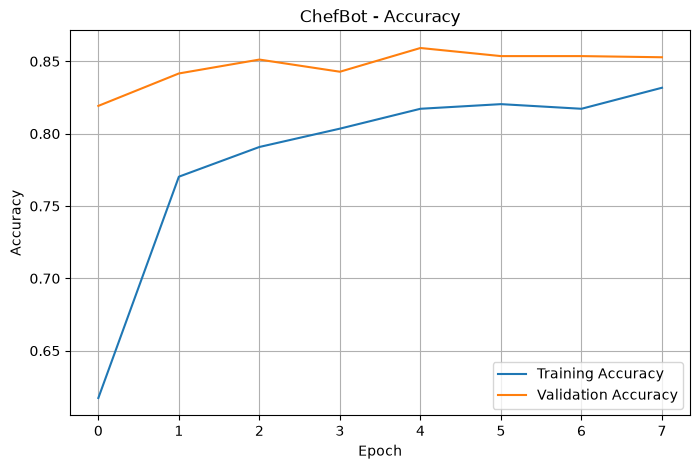

In [48]:
# ==============================================================================
# GRAFICO ACCURACY
# ==============================================================================

plt.figure(figsize=(8, 5))
plt.plot(history_head.history["accuracy"],label="Training Accuracy")
plt.plot(history_head.history["val_accuracy"],label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ChefBot - Accuracy")
plt.legend()
plt.grid()
plt.show()

Conferma quanto già detto.
L'addestramento è riuscito bene e non mostra segni di overfitting
La Training Accuracy (blu) cresce, il salto maggiore avviene tra la prima e la seconda epoca. Dopo l'epoca 4 la crescita rallenta
La Validation Accuracy (aracio) parte molto alta per poi oscillare sempre intorno all 85%
Il punto migliore è all'epoca 5

Analisi della Loss

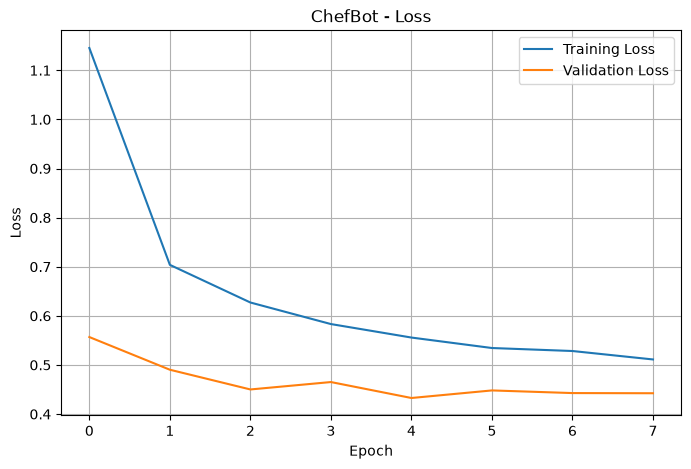

In [49]:
# ==============================================================================
# GRAFICO LOSS
# ==============================================================================

plt.figure(figsize=(8, 5))
plt.plot(history_head.history["loss"], label="Training Loss")
plt.plot(history_head.history["val_loss"],label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ChefBot - Loss")
plt.legend()
plt.grid()
plt.show()

Grafico buono
La training Loss scende in modo regolare, quindi il modello impara progressivamente. Non ci sono impennate o instabilità
La Validation Loss ha un minimo all'epoca 5 e poi aumenta leggermente.
Il punto migliore è quindi l'epoca 5

FINE-TUNNING
Dopo aver addestrato, sblocco una piccola parte della rete (non tutto)

In [50]:
# ==============================================================================
# FINE-TUNING
# ==============================================================================

base_model.trainable = True
FINE_TUNE_LAYERS = 30
fine_tune_at = (len(base_model.layers)- FINE_TUNE_LAYERS)

# Metto congelati tutti i layer precedenti

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Metto congelate le BatchNormalization
for layer in base_model.layers[fine_tune_at:]:
    if isinstance(layer,layers.BatchNormalization):
        layer.trainable = False

print("Layer totali:",len(base_model.layers))
print("Layer utilizzati per fine-tuning:",FINE_TUNE_LAYERS)

Layer totali: 154
Layer utilizzati per fine-tuning: 30


Ricompilazoine modello
utilizzo lr basso

In [51]:
# ==============================================================================
# RICOMPILAZIONE
# ==============================================================================

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE_FINE),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")    ]
)

Callback per fine-tuning

In [52]:
# ==============================================================================
# CALLBACK FINE-TUNING
# ==============================================================================

callbacks_fine = [
    keras.callbacks.EarlyStopping(monitor="val_loss",patience=3,restore_best_weights=True,verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss",factor=0.5,patience=2,min_lr=1e-7,verbose=1),
    keras.callbacks.ModelCheckpoint(FINE_MODEL_PATH,monitor="val_accuracy",save_best_only=True,mode="max",verbose=1)
]

Training del fine-tuning

Il modello parte dai pesi dell'epoca 5 perchè inteventua la callback
Il modello era arrivato all'epoca 8
Ripristinati pesi dell'epoca 5 da EarlyStopping con restore_best_weights=True.

Quindi fa:
pesi epoca 5 - sblocco ultimi layer - nuovo training -etichetta sul log: epoca 9

In [53]:
# ==============================================================================
# TRAINING FINE-TUNING
# ==============================================================================

initial_epoch = len(history_head.epoch)
history_fine = model.fit(
    ds_train,
    validation_data=dt_test,
    initial_epoch=initial_epoch,
    epochs=(initial_epoch + EPOCHS_FINE_TUNING),
    callbacks=callbacks_fine
)

Epoch 9/16
    235/Unknown 90s 351ms/step - accuracy: 0.8281 - loss: 0.5189
Epoch 9: val_accuracy improved from None to 0.86040, saving model to chefbot_finetuned.keras

Epoch 9: finished saving model to chefbot_finetuned.keras
235/235 ━━━━━━━━━━━━━━━━━━━━ 107s 426ms/step - accuracy: 0.8281 - loss: 0.5189 - val_accuracy: 0.8604 - val_loss: 0.4237 - learning_rate: 1.0000e-05
Epoch 10/16
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.8411 - loss: 0.4710
Epoch 10: val_accuracy improved from 0.86040 to 0.86400, saving model to chefbot_finetuned.keras

Epoch 10: finished saving model to chefbot_finetuned.keras
235/235 ━━━━━━━━━━━━━━━━━━━━ 79s 330ms/step - accuracy: 0.8411 - loss: 0.4710 - val_accuracy: 0.8640 - val_loss: 0.4157 - learning_rate: 1.0000e-05
Epoch 11/16
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.8555 - loss: 0.4331
Epoch 11: val_accuracy did not improve from 0.86400
235/235 ━━━━━━━━━━━━━━━━━━━━ 79s 329ms/step - accuracy: 0.8555 - loss: 0.4331 - val_accu

Il traninig non è stato fermato da earlystopping, valutando un possibile un aumento delle epoche, decido di non aumentare per valori di loss e accuracy buoni e migliorati rispetto a prima del fine-tunning. Valuterò dopo confusion-matrix
Accuracy e Loss migliorano continuamente sia sul train set che sul validation set (solo un leggero peggioramento per Accuracy della validation all'epoca 13) e non mostrano sintomi di overfitting
Alla fine ottengo:
Training accuracy = 88.88%
Validation accuracy= 87.84%
Training Loss = 0.33
Validation Loss = 0.37
Migliorando tuto rispetto all'epoca 9 di partenza

Modello fine-tuned caricato correttamente.
Numero immagini valutate: 2500
Prime label reali:     [3 7 5 5 7 8 2 8 5 4 7 4 3 2 4 0 2 8 7 5]
Prime label previste:  [6 7 5 5 7 8 2 8 5 4 7 4 3 2 4 6 2 8 7 5]

CLASSIFICATION REPORT

                precision    recall  f1-score   support

     apple_pie     0.7699    0.7360    0.7526       250
  caesar_salad     0.9016    0.8800    0.8907       250
    cheesecake     0.8264    0.8760    0.8505       250
fish_and_chips     0.9402    0.8800    0.9091       250
   greek_salad     0.9191    0.8640    0.8907       250
     hamburger     0.8640    0.9400    0.9004       250
     ice_cream     0.9076    0.8640    0.8852       250
       lasagna     0.8427    0.9000    0.8704       250
         pizza     0.9320    0.9320    0.9320       250
         sushi     0.8906    0.9120    0.9012       250

      accuracy                         0.8784      2500
     macro avg     0.8794    0.8784    0.8783      2500
  weighted avg     0.8794    0.8784    0.8

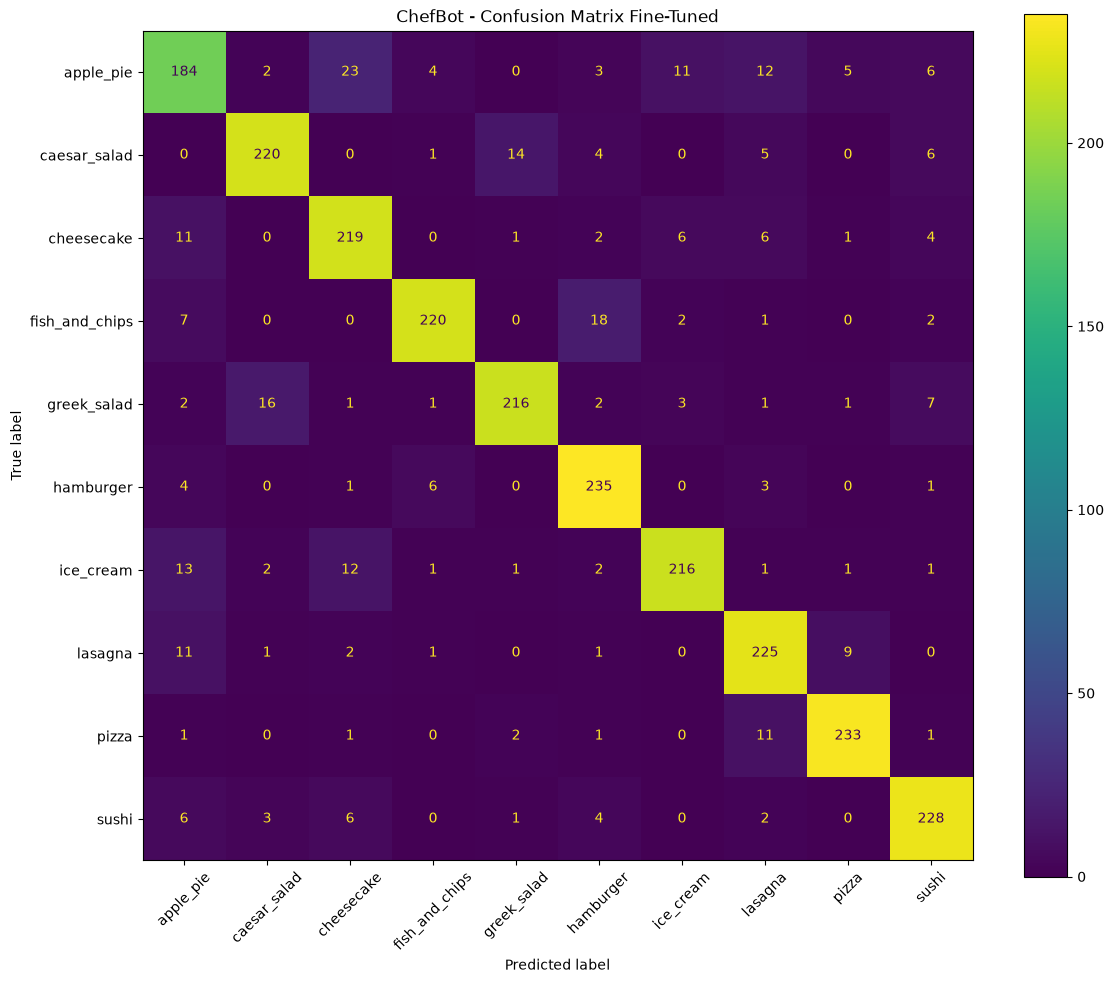

In [ ]:
# ==============================================================================
# CLASSIFICATION REPORT + CONFUSION MATRIX
# ==============================================================================

# ------------------------------------------------------------------------------
# 1. CARICAMENTO DEL MIGLIOR MODELLO FINE-TUNED
# ------------------------------------------------------------------------------

model_finetuned = keras.models.load_model("chefbot_finetuned.keras")
print("Modello fine-tuned caricato correttamente.")

# ------------------------------------------------------------------------------
# 2. ESTRAZIONE LABEL REALI E PREDIZIONI
# ------------------------------------------------------------------------------

y_true = []
y_pred = []

for images, labels in dt_test:
    # Predizione
    predictions = model_finetuned.predict( images,verbose=0    )
    # Label reali
    y_true.extend(labels.numpy())
    # Classe con probabilità maggiore
    predicted_classes = np.argmax(predictions,axis=1)
    y_pred.extend(predicted_classes)

# Converto le liste in array NumPy
y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Numero immagini valutate:", len(y_true))
print("Prime label reali:    ", y_true[:20])
print("Prime label previste: ", y_pred[:20])


# ------------------------------------------------------------------------------
# 3. CLASSIFICATION REPORT
# ------------------------------------------------------------------------------

print("\nCLASSIFICATION REPORT\n")
print(classification_report(y_true,y_pred,target_names=SELECTED_CLASSES,digits=4))

# ------------------------------------------------------------------------------
# 4. CONFUSION MATRIX
# ------------------------------------------------------------------------------
cm = confusion_matrix(y_true,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=SELECTED_CLASSES)
fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(ax=ax,xticks_rotation=45,values_format="d")
plt.title("ChefBot - Confusion Matrix Fine-Tuned")
plt.tight_layout()
plt.show()

Il test set risulta bilanciato 250 immagini per tutte le classi, totale immagini 2.500.
In questo modo l'accuracy non risulta falsata da classi sbilanciate
Il risultato totale è Accuracy 0.8784 = 87.84%, questo significa che su 2500 immagini 2196 sono state classificate correttamente, sbagliandone 304
La classe migliore è 'pizza' con precision e recall al 93.2% (233 corrette, 17 sbagliate)
Hamburger, con una precision di 86,4% ed una recall 94% vuol dire che quasi tutti gli hamburger sono trovati (235 su 250) ma si tende a chiamare hamburger anche qualcosa che non lo è
Fish & chip spesso confusa con hambuerger
La classe peggiore è apple_pie, precisione 76,99% reall 73.3% F1 75.26%. Su 250 apple_pie il modello ne riconosce solo 184, sbagliandone 66. Dalla confusion matrix si nota che è spesso confusa con ice-cream, cheesecake (ragionevoli), mentre è interessante la confusione con lasagna
La confusione tra caeser_salad e greek_salad ha senso, entrambe insalate verdi, non la considero una vera anomalia del modello, ma una difficoltà reale

Con queste informazioni non cambierei modello o numero epoche. continuo con l'esercizio

KNOWLEDGE BASE
Devo associare ad ogni piatto: ingredienti, calorie stimate, descrizione.
Creo una funzione che lo faccia

In [58]:
# ==============================================================================
# KNOWLEDGE BASE
# ==============================================================================

knowledge_base = {
    "apple_pie": {
        "nome": "Apple Pie",
        "ingredienti_principali": [
            "mele",
            "farina",
            "burro",
            "zucchero",
            "cannella"
        ],
        "calorie_kcal_stimate": 320,
        "descrizione":
            "Torta di mele dolce e profumata con "
            "ripieno di mele e cannella."
    },
    "caesar_salad": {
        "nome": "Caesar Salad",
        "ingredienti_principali": [
            "lattuga romana",
            "parmigiano",
            "crostini",
            "salsa Caesar"
        ],
        "calorie_kcal_stimate": 350,
        "descrizione":
            "Insalata fresca e croccante con lattuga, "
            "parmigiano e crostini."
    },
    "cheesecake": {
        "nome": "Cheesecake",
        "ingredienti_principali": [
            "formaggio cremoso",
            "biscotti",
            "burro",
            "zucchero"
        ],
        "calorie_kcal_stimate": 400,
        "descrizione":
            "Dessert cremoso e ricco con base "
            "croccante di biscotti."
    },
    "fish_and_chips": {
        "nome": "Fish and Chips",
        "ingredienti_principali": [
            "pesce",
            "patate",
            "farina",
            "olio"
        ],
        "calorie_kcal_stimate": 800,
        "descrizione":
            "Pesce fritto in pastella accompagnato "
            "da patatine fritte."
    },
    "greek_salad": {
        "nome": "Greek Salad",
        "ingredienti_principali": [
            "pomodori",
            "cetrioli",
            "feta",
            "olive",
            "cipolla"
        ],
        "calorie_kcal_stimate": 250,
        "descrizione":
            "Insalata mediterranea fresca e leggera "
            "con verdure, feta e olive."
    },
    "hamburger": {
        "nome": "Hamburger",
        "ingredienti_principali": [
            "pane",
            "carne",
            "formaggio",
            "insalata",
            "pomodoro"
        ],
        "calorie_kcal_stimate": 550,
        "descrizione":
            "Panino sostanzioso con carne "
            "e diversi condimenti."
    },
    "ice_cream": {
        "nome": "Ice Cream",
        "ingredienti_principali": [
            "latte",
            "panna",
            "zucchero"
        ],
        "calorie_kcal_stimate": 250,
        "descrizione":
            "Dessert freddo, dolce e cremoso."
    },
    "lasagna": {
        "nome": "Lasagna",
        "ingredienti_principali": [
            "pasta",
            "ragù",
            "besciamella",
            "parmigiano"
        ],
        "calorie_kcal_stimate": 500,
        "descrizione":
            "Piatto caldo e sostanzioso composto "
            "da strati di pasta, ragù e besciamella."
    },
    "pizza": {
        "nome": "Pizza",
        "ingredienti_principali": [
            "farina",
            "pomodoro",
            "mozzarella",
            "olio"
        ],
        "calorie_kcal_stimate": 700,
        "descrizione":
            "Piatto italiano con impasto lievitato, "
            "pomodoro e mozzarella."
    },
    "sushi": {
        "nome": "Sushi",
        "ingredienti_principali": [
            "riso",
            "pesce",
            "alga nori",
            "verdure"
        ],
        "calorie_kcal_stimate": 400,
        "descrizione":
            "Piatto giapponese fresco e delicato "
            "a base di riso e pesce."
    }
}

In [59]:
# ==============================================================================
# SALVATAGGIO KNOWLEDGE BASE
# ==============================================================================

with open(KNOWLEDGE_PATH,"w",encoding="utf-8") as file:
    json.dump(knowledge_base,file,ensure_ascii=False,indent=4)

print(f"Knowledge Base salvata in: {KNOWLEDGE_PATH}")

Knowledge Base salvata in: chefbot_knowledge.json


In [62]:
# ==============================================================================
# CARICAMENTO KNOWLEDGE BASE
# ==============================================================================

def load_knowledge_base(path=KNOWLEDGE_PATH):
    with open(path,"r",encoding="utf-8") as file:
        return json.load(file)

knowledge_base = load_knowledge_base()
print(f"Knowledge: {knowledge_base}")

Knowledge: {'apple_pie': {'nome': 'Apple Pie', 'ingredienti_principali': ['mele', 'farina', 'burro', 'zucchero', 'cannella'], 'calorie_kcal_stimate': 320, 'descrizione': 'Torta di mele dolce e profumata con ripieno di mele e cannella.'}, 'caesar_salad': {'nome': 'Caesar Salad', 'ingredienti_principali': ['lattuga romana', 'parmigiano', 'crostini', 'salsa Caesar'], 'calorie_kcal_stimate': 350, 'descrizione': 'Insalata fresca e croccante con lattuga, parmigiano e crostini.'}, 'cheesecake': {'nome': 'Cheesecake', 'ingredienti_principali': ['formaggio cremoso', 'biscotti', 'burro', 'zucchero'], 'calorie_kcal_stimate': 400, 'descrizione': 'Dessert cremoso e ricco con base croccante di biscotti.'}, 'fish_and_chips': {'nome': 'Fish and Chips', 'ingredienti_principali': ['pesce', 'patate', 'farina', 'olio'], 'calorie_kcal_stimate': 800, 'descrizione': 'Pesce fritto in pastella accompagnato da patatine fritte.'}, 'greek_salad': {'nome': 'Greek Salad', 'ingredienti_principali': ['pomodori', 'cet

Funzione Lookup
riceve la classe predetta dal modello e restituisce le informazioni dal JSON (Knowledge)

In [69]:
# ==============================================================================
# LOOKUP
# ==============================================================================

def lookup_piatto(predicted_class,knowledge_base):
    return knowledge_base.get(predicted_class)

Visualizzazione della scheda

In [63]:
# ==============================================================================
# SCHEDA INFORMATIVA
# ==============================================================================

def mostra_scheda(class_name,confidence,knowledge_base):
    info = lookup_piatto(class_name,knowledge_base)
    if info is None:
        print("Informazioni non disponibili." )
        return
    print("**************************")
    print(f"PIATTO: {info['nome']}")
    print(f"Confidenza: {confidence:.2%}" )
    print("**************************")
    print("Ingredienti principali:")
    for ingredient in info["ingredienti_principali"]:
        print(f"- {ingredient}")
    print(f"\nCalorie stimate: {info['calorie_kcal_stimate']} kcal")
    print(f"\nDescrizione:\n{info['descrizione']}")
    print("**************************")


Predizione nuova immagine (.predict)
Prendo l'immagie, la preparo, con predict chiedo al modello di classificarla e restituisce la classe prevista

In [ ]:
# ==============================================================================
# PREDIZIONE NUOVA IMMAGINE
# ==============================================================================

# image_path=percorso immagine
# model= modello ChefBot addestrato
# class_names = elenco classi
def predici_immagine(image_path,model,class_names):
    image = keras.utils.load_img(image_path,target_size=IMG_SIZE) #carico l'immagine dal disco e la ridimensiono
    image_array = keras.utils.img_to_array(image) #trasformo in array numerico
    #print(image_array.shape)
    image_batch = np.expand_dims(image_array,axis=0) #aggiungo una dimesione davanti, perchè il modello si aspetta un batch (passo al modello un batch con una sola immagine)
    #print(image_batch.shape)
    probabilities = model.predict(image_batch,verbose=0)[0] #predict con tutte le probabilità
    predicted_index = np.argmax(probabilities) #indice della classa con probabilità maggiore
    predicted_class = class_names[predicted_index] #trasformo nella classe comprensibile
    confidence = float(probabilities[predicted_index]) #probabilità della classe 'vincente'
    return (image,predicted_class,confidence,probabilities) #restituisco tutto


foto -> classificazione -> Knowledge base

In [66]:
# ==============================================================================
# CHEFBOT DA FOTO
# ==============================================================================

def chefbot_da_foto(image_path,model=model_finetuned):
    (image,predicted_class,confidence,probabilities) = predici_immagine(image_path,model,SELECTED_CLASSES)

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.title(f"{predicted_class} - {confidence:.2%}")
    plt.axis("off")
    plt.show()
    mostra_scheda(predicted_class,confidence,knowledge_base)
    return (predicted_class,confidence)

(224, 224, 3)
(1, 224, 224, 3)


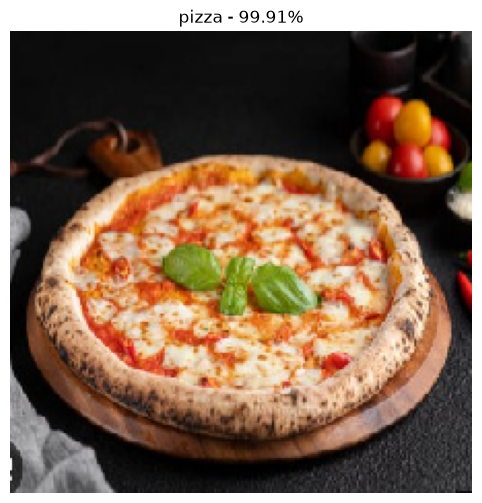

**************************
PIATTO: Pizza
Confidenza: 99.91%
**************************
Ingredienti principali:
- farina
- pomodoro
- mozzarella
- olio

Calorie stimate: 700 kcal

Descrizione:
Piatto italiano con impasto lievitato, pomodoro e mozzarella.
**************************


('pizza', 0.999122679233551)

In [70]:
#esempio
chefbot_da_foto("pizza test.jpg")

Ricerca semantica
Utilizzo un Sentenct Transformer multilingua
Preparo la parte NLP. 
Carico un modello che mi trasforma le frasi in vettori numerici (embedding) per confrontare frasi semanticamente
Mi restituirà un vettore, che rappresenta, in modo approssimativo, il significato delle frase.
Prendo un modello multlingua

In [71]:
# ==============================================================================
# SENTENCE TRANSFORMER
# ==============================================================================

# Scelta del modello
EMBEDDING_MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
print("Caricamento modello NLP...")
# creo l'oggetto che userò per trasformare testi in embedding
embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)
print("Modello NLP caricato.")

Caricamento modello NLP...


c:\EPICODE\Epicode_Python_AI_MachineLearning\.venv\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\barbara\.cache\huggingface\hub\models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 

Modello NLP caricato.


In [80]:
#prova modello embedding
from sklearn.metrics.pairwise import cosine_similarity

embedding_frase1 = embedding_model.encode("Vorrei pizza margherita")
embedding_frase2 = embedding_model.encode("Vorrei qualcosa con pomodoro e mozzarella")
#print(embedding_frase1)
#embedding_frase1.shape
similarity = cosine_similarity([embedding_frase1], [embedding_frase2])[0][0]
print(f"Similarità coseno: {similarity:.4f}")

Similarità coseno: 0.7053


Costruzione del testo semantico

In [82]:
# ==============================================================================
# TESTO SEMANTICO DEI PIATTI
# ==============================================================================

def crea_testo_semantico(info):
    ingredients = ", ".join(info["ingredienti_principali"] )
    text = (f"{info['nome']}. {info['descrizione']} Ingredienti principali: {ingredients}.")
    return text

In [84]:
#esempio di utilizzo
info_pizza = knowledge_base["pizza"]
testo_pizza = crea_testo_semantico(info_pizza)
print(testo_pizza)

Pizza. Piatto italiano con impasto lievitato, pomodoro e mozzarella. Ingredienti principali: farina, pomodoro, mozzarella, olio.


Catalogo dei piatti
che utilizzerò per confrontare una frase dell'utente con i piatti di ChefBot

In [86]:
# ==============================================================================
# CORPUS SEMANTICO
# che passerò al Sentecnt Transformer per l'embedding
# ==============================================================================

#prendo le chiavi del knowledeg_base (pizza, sushi, ice_cream, ecc) e le metto in una lista
dish_keys = list(knowledge_base.keys())

# mi passa nome, descrizione e ingredienti
dish_texts = []
for key in dish_keys:
    testo = crea_testo_semantico(knowledge_base[key])
    dish_texts.append(testo)

#stampo tutto
for key, text in zip(dish_keys,dish_texts):
    print(f"\n{key}:")
    print(text)


apple_pie:
Apple Pie. Torta di mele dolce e profumata con ripieno di mele e cannella. Ingredienti principali: mele, farina, burro, zucchero, cannella.

caesar_salad:
Caesar Salad. Insalata fresca e croccante con lattuga, parmigiano e crostini. Ingredienti principali: lattuga romana, parmigiano, crostini, salsa Caesar.

cheesecake:
Cheesecake. Dessert cremoso e ricco con base croccante di biscotti. Ingredienti principali: formaggio cremoso, biscotti, burro, zucchero.

fish_and_chips:
Fish and Chips. Pesce fritto in pastella accompagnato da patatine fritte. Ingredienti principali: pesce, patate, farina, olio.

greek_salad:
Greek Salad. Insalata mediterranea fresca e leggera con verdure, feta e olive. Ingredienti principali: pomodori, cetrioli, feta, olive, cipolla.

hamburger:
Hamburger. Panino sostanzioso con carne e diversi condimenti. Ingredienti principali: pane, carne, formaggio, insalata, pomodoro.

ice_cream:
Ice Cream. Dessert freddo, dolce e cremoso. Ingredienti principali: lat

Generazione degli embedding
prendo tutti i testi dei piatti generati prima e le trasformo in vettori numerici (embedding) utilizzando il modello scelto ("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
Al termine ogni testo sarà rappresentato da un vettore con 384 numeri

In [87]:
# ==============================================================================
# EMBEDDING DEI PIATTI
# ==============================================================================

dish_embeddings = embedding_model.encode(dish_texts,convert_to_tensor=True) #restituisce un tensore
print("Dimensione embedding:")
print(dish_embeddings.shape)

Dimensione embedding:
torch.Size([10, 384])


Cosine Similarity
Ricerca per umore

Prendo una frase dell'utente, la trasformo in embedding, la confronto con gli embedding dei 10 piatti e ristituisco top 3 (piatti semanticamente vicini)

In [90]:
# ==============================================================================
# RICERCA SEMANTICA PER UMORE
# ==============================================================================

def ricerca_per_umore(query,top_k=3):
    #creo embedding della richiestas utente (query)
    query_embedding = embedding_model.encode(query, convert_to_tensor=True)
    #calcolo la similarità con tutti i piatti
    similarities = cos_sim(query_embedding,dish_embeddings)[0] #confronto il vettore (embedding) della frase (query) con tutti i vettori dei piatti (dish_embeddings) creato prima
    #converto in array numpy
    similarity_scores = (similarities.cpu().numpy())
    #Ordino dalla similarità maggiore alla minore
    best_indices = np.argsort(similarity_scores)[::-1] #ordino dal più piccolo al più grande poi lo ribalto (dal più grande al più piccolo)
    top_k = min(top_k,len(best_indices))
    results = [] #lista vuota dove metterò i risultati
    #recupero i migliori k risultati
    for index in best_indices[:top_k]:
        class_name = dish_keys[index]
        info = knowledge_base[class_name]
        results.append({
            "classe": class_name, 
            "nome": info["nome"], 
            "similarita": float(similarity_scores[index]),
            "descrizione": info["descrizione"],
            "calorie_kcal_stimate": info["calorie_kcal_stimate"]
            }
        )

    return results

In [91]:
#esempio di utilizzo
risultati = ricerca_per_umore("Vorrei qualcosa di fresco e leggero")
for risultato in risultati:
    print(risultato["nome"],risultato["similarita"])

Lasagna 0.4465653896331787
Ice Cream 0.40014970302581787
Cheesecake 0.295735627412796


Valutazione delle ricerca semantica

In [94]:
# ==============================================================================
# VISUALIZZAZIONE RISULTATI
# ==============================================================================

def mostra_ricerca_per_umore(query,top_k=3):
    results = ricerca_per_umore(query,top_k)
    print(f"\n\n****************************")
    print(f"RICERCA: {query}")
    print("****************************")
    for position, result in enumerate(results,start=1):
        print(f"\n{position}. {result['nome']}")
        print(f"Similarità: {result['similarita']:.4f}")
        print(f"Calorie stimate: {result['calorie_kcal_stimate']} kcal")
        print(result["descrizione"])

    return results

Test ricerca per umore

In [95]:
mostra_ricerca_per_umore("voglio qualcosa di fresco e leggero")
mostra_ricerca_per_umore("voglio un dolce con frutta fresca")
mostra_ricerca_per_umore("voglio qualcosa di caldo")



****************************
RICERCA: voglio qualcosa di fresco e leggero
****************************

1. Lasagna
Similarità: 0.4412
Calorie stimate: 500 kcal
Piatto caldo e sostanzioso composto da strati di pasta, ragù e besciamella.

2. Ice Cream
Similarità: 0.3765
Calorie stimate: 250 kcal
Dessert freddo, dolce e cremoso.

3. Caesar Salad
Similarità: 0.2869
Calorie stimate: 350 kcal
Insalata fresca e croccante con lattuga, parmigiano e crostini.


****************************
RICERCA: voglio un dolce con frutta fresca
****************************

1. Ice Cream
Similarità: 0.5545
Calorie stimate: 250 kcal
Dessert freddo, dolce e cremoso.

2. Apple Pie
Similarità: 0.5445
Calorie stimate: 320 kcal
Torta di mele dolce e profumata con ripieno di mele e cannella.

3. Lasagna
Similarità: 0.5060
Calorie stimate: 500 kcal
Piatto caldo e sostanzioso composto da strati di pasta, ragù e besciamella.


****************************
RICERCA: voglio qualcosa di caldo
****************************

[{'classe': 'lasagna',
  'nome': 'Lasagna',
  'similarita': 0.5217869281768799,
  'descrizione': 'Piatto caldo e sostanzioso composto da strati di pasta, ragù e besciamella.',
  'calorie_kcal_stimate': 500},
 {'classe': 'ice_cream',
  'nome': 'Ice Cream',
  'similarita': 0.40758514404296875,
  'descrizione': 'Dessert freddo, dolce e cremoso.',
  'calorie_kcal_stimate': 250},
 {'classe': 'cheesecake',
  'nome': 'Cheesecake',
  'similarita': 0.33139142394065857,
  'descrizione': 'Dessert cremoso e ricco con base croccante di biscotti.',
  'calorie_kcal_stimate': 400}]

FUNZIONE FINALE DI CHEFBOT

Questa funzione non addestra nulla, coordina le funzioni costruite

chefbot se riceve una foto: chefbot_da_foto() -> classificazione immagine
chefbot se riceve una frase: mostra_ricerca_per_umore() -> ricerca semantica

In [98]:
# ==============================================================================
# CHEFBOT AI
# ==============================================================================

def chefbot(image_path=None,umore=None): #può ricevere un immagine o un testo
    print(f"\n************************")
    print("CHEFBOT AI - DALLO SCATTO ALLA RICETTA")
    print(f"************************")

    # ==========================================================================
    # RICONOSCIMENTO IMMAGINE
    # ==========================================================================

    if image_path is not None:
        print("\nRICONOSCIMENTO IMMAGINE\n")
        chefbot_da_foto(image_path,model=model_finetuned)

    # ==========================================================================
    # RICERCA SEMANTICA
    # ==========================================================================

    if umore is not None:
        print("\nRICERCA PER UMORE\n")
        mostra_ricerca_per_umore(umore,top_k=3)

    # ==========================================================================
    # CONTROLLO INPUT
    # ==========================================================================

    if (image_path is None and umore is None):
        print("Specificare una fotografia oppure una frase.")


************************
CHEFBOT AI - DALLO SCATTO ALLA RICETTA
************************

RICONOSCIMENTO IMMAGINE

(224, 224, 3)
(1, 224, 224, 3)


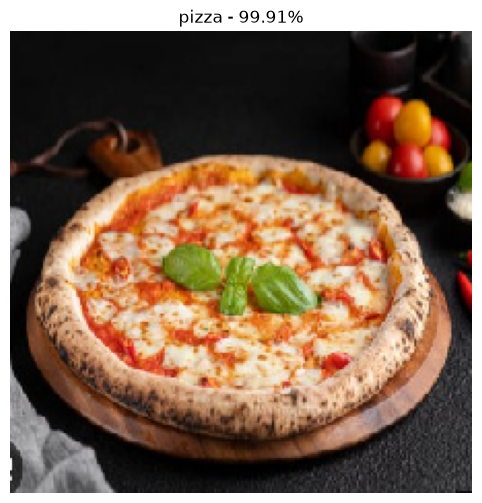

**************************
PIATTO: Pizza
Confidenza: 99.91%
**************************
Ingredienti principali:
- farina
- pomodoro
- mozzarella
- olio

Calorie stimate: 700 kcal

Descrizione:
Piatto italiano con impasto lievitato, pomodoro e mozzarella.
**************************


In [99]:
chefbot(image_path="pizza test.jpg")

In [100]:
chefbot(umore="Vorrei una pizza")


************************
CHEFBOT AI - DALLO SCATTO ALLA RICETTA
************************

RICERCA PER UMORE



****************************
RICERCA: Vorrei una pizza
****************************

1. Pizza
Similarità: 0.6499
Calorie stimate: 700 kcal
Piatto italiano con impasto lievitato, pomodoro e mozzarella.

2. Lasagna
Similarità: 0.3815
Calorie stimate: 500 kcal
Piatto caldo e sostanzioso composto da strati di pasta, ragù e besciamella.

3. Greek Salad
Similarità: 0.3764
Calorie stimate: 250 kcal
Insalata mediterranea fresca e leggera con verdure, feta e olive.


In [101]:
chefbot(umore="Vorrei qualcosa di fresco")


************************
CHEFBOT AI - DALLO SCATTO ALLA RICETTA
************************

RICERCA PER UMORE



****************************
RICERCA: Vorrei qualcosa di fresco
****************************

1. Lasagna
Similarità: 0.4462
Calorie stimate: 500 kcal
Piatto caldo e sostanzioso composto da strati di pasta, ragù e besciamella.

2. Ice Cream
Similarità: 0.3967
Calorie stimate: 250 kcal
Dessert freddo, dolce e cremoso.

3. Caesar Salad
Similarità: 0.3069
Calorie stimate: 350 kcal
Insalata fresca e croccante con lattuga, parmigiano e crostini.
